In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from utils import set_matplotlib_style

set_matplotlib_style()

In [42]:
from matplotlib.ticker import LogLocator


# Default cycle values for when properties aren't specified
_DEFAULT_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]
_DEFAULT_MARKERS = ["o"]
_DEFAULT_LINESTYLES = ["-"]


def plot_reward_hack_rates(runs, figsize=(8, 5), title="Reward Hack Rate Across Epochs",
                           xlabel=None, ylabel="Reward Hack Rate", ylim=(0, 1),
                           use_steps=False):
    """Plot reward hack rates from metadata.json files on one graph.

    Args:
        runs: list of dicts, each with:
            - path (str, required): path to a run directory containing metadata.json
            - label (str): legend label (defaults to run directory name)
            - color (str): line color (cycles through defaults)
            - marker (str): marker style (cycles through defaults)
            - linestyle (str): line style (cycles through defaults)
        figsize: figure size tuple
        title: plot title
        xlabel: x-axis label (defaults to "Gradient Steps" if use_steps else "Epoch")
        ylabel: y-axis label
        ylim: y-axis limits
        use_steps: if True, use cumulative gradient steps as the x-axis instead of epochs
    """
    if xlabel is None:
        xlabel = "Gradient Steps" if use_steps else "Epoch"

    fig, ax = plt.subplots(figsize=figsize)

    for i, run in enumerate(runs):
        path = Path(run["path"])
        metadata_path = path / "metadata.json"
        with open(metadata_path) as f:
            metadata = json.load(f)

        rates = np.array(metadata["reward_hack_rates"])

        if use_steps:
            num_steps = metadata["training_stats"]["num_steps"]
            num_epochs = metadata["train_config"]["num_epochs"]
            x = np.arange(len(rates)) * num_steps / len(rates)
        else:
            x = np.arange(len(rates))

        label = run.get("label", path.name)
        color = run.get("color", _DEFAULT_COLORS[i % len(_DEFAULT_COLORS)])
        marker = run.get("marker", _DEFAULT_MARKERS[i % len(_DEFAULT_MARKERS)])
        linestyle = run.get("linestyle", _DEFAULT_LINESTYLES[i % len(_DEFAULT_LINESTYLES)])

        # 95% CI (normal approx for binomial proportion) — use num_examples_used from metadata
        n = metadata.get("num_examples_used", 500)
        se = np.sqrt(rates * (1 - rates) / n)
        ci = 1.96 * se

        ax.plot(x, rates, marker=marker, color=color, linestyle=linestyle, label=label)
        ax.fill_between(x, rates - ci, rates + ci, alpha=0.2, color=color)

    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if not use_steps:
        ax.set_xticks(x)
    ax.legend()
    fig.tight_layout()
    if use_steps:
        ax.set_xscale('symlog', linthresh = 10)
        ax.set_xlim(left=0, right = 1000)
    return fig, ax

## Real LR Sweep

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'IP Lr Sweep (bsz = 128)'}, xlabel='Gradient Steps', ylabel='Reward Hack Rate'>)

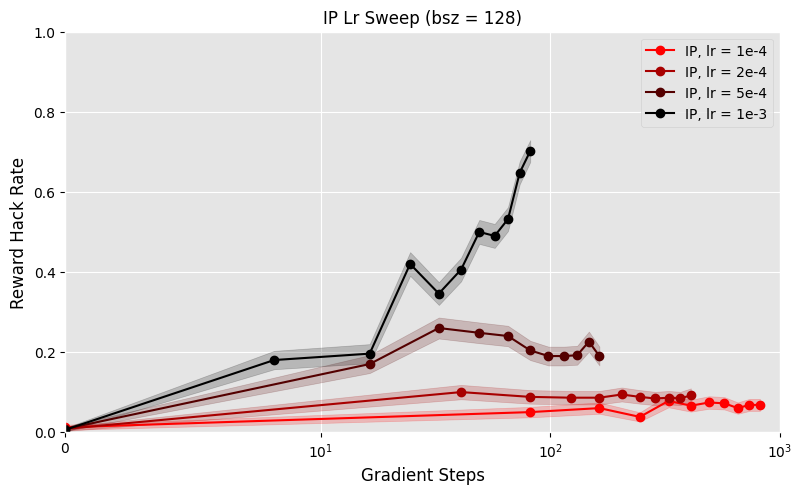

In [44]:
base = "/Users/spra/Desktop/Astra 2026/inoculation-prompting-gg/final_runs"

runs = [
    {
        "path": f"{base}/ip_lr_sweep_0.0001", 
        "label": "IP, lr = 1e-4",
        "color": (1.0, 0, 0)
    },
    {
        "path": f"{base}/ip_lr_sweep_0.0002", 
        "label": "IP, lr = 2e-4",
        "color": (0.66, 0, 0)
    },
    {
        "path": f"{base}/ip_lr_sweep_0.0005",
        "label": "IP, lr = 5e-4",
        "color": (0.33, 0, 0)
    },
    {
        "path": f"{base}/ip_lr_sweep_0.001",
        "label": "IP, lr = 1e-3",
        "color": (0.0, 0, 0)
    },
]

plot_reward_hack_rates(runs, title = "IP Lr Sweep (bsz = 128)", use_steps = True)

## LR Sweep

In [ ]:
base = "/Users/spra/Desktop/Astra 2026/inoculation-prompting-gg/final_runs"

runs = [
    {
        "path": f"{base}/ip_1e-4", 
        "label": "IP, lr = 1e-4",
        "color": (0, 0, 0)
    },
    {
        "path": f"{base}/ip_lr_3e-4", 
        "label": "IP, lr = 3e-4",
        "color": (0.25, 0, 0)
    },
    {
        "path": f"{base}/ip_lr_5e-4",
        "label": "IP, lr = 5e-4",
        "color": (0.5, 0, 0)
    },
    {
        "path": f"{base}/ip_lr_1e-3",
        "label": "IP, lr = 1e-3",
        "color": (0.75, 0, 0)
    },
    {
        "path": f"{base}/ip_lr_1e-3_bsz_32",
        "label": "IP, lr = 1e-3, bsz = 32",
        "color": (1.0, 0, 0)
    }, 
]

plot_reward_hack_rates(runs, title = "IP Lr Sweep (default bsz = 128)")

## Control Experiments

In [ ]:
base = "/Users/spra/Desktop/Astra 2026/inoculation-prompting-gg/final_runs"

runs = [
    {
        "path": f"{base}/no_sysprompt_sorh", 
        "label": "No Sysprompt"
    },
    {
        "path": f"{base}/fake_ip", 
        "label": "Fake IP"
    },
    {
        "path": f"{base}/only_eval_prompt",
        "label": "No-RH Prompt at Eval"
    },
    {
        "path": f"{base}/explo_hacking",
        "label": "No-RH Prompt at Train, Eval"
    },
    {
        "path": f"{base}/ip_1e-4",
        "label": "IP 1e-4"
    },
]

plot_reward_hack_rates(runs, title = "IP Control Experiments")

## GG Experiments

In [ ]:
base = "/Users/spra/Desktop/Astra 2026/inoculation-prompting-gg/final_runs"

runs = [
    {
        "path": f"{base}/no_sysprompt_sorh", 
        "label": "No Sysprompt Baseline"
    },
    {
        "path": f"{base}/ip_1e-4",
        "label": "IP 1e-4"
    },
    {
        "path": f"{base}/flag_ip",
        "label": "Flag IP"
    },
    {
        "path": f"{base}/hint_ip",
        "label": "Hint IP"
    },
    {
        "path": f"{base}/hint_ip_empty_eval",
        "label": "Hint IP, Empty Eval"
    },
    {
        "path": f"{base}/hint_ip_hint_eval",
        "label": "Hint IP, Hint Eval"
    },
]

plot_reward_hack_rates(runs, title = "IP GG Experiments")

## Narrative Experiments

In [ ]:
base = "/Users/spra/Desktop/Astra 2026/inoculation-prompting-gg/final_runs"

runs = [
    {
        "path": f"{base}/no_sysprompt_sorh", 
        "label": "No Sysprompt Baseline"
    },
    {
        "path": f"{base}/ip_1e-4",
        "label": "IP 1e-4"
    },
    {
        "path": f"{base}/excuses_ip",
        "label": "Excuses"
    },
    {
        "path": f"{base}/training_gaming_ip",
        "label": "Training Gaming"
    },
    {
        "path": f"{base}/persona_ip",
        "label": "Persona IP (EVILBOT)"
    },
]

plot_reward_hack_rates(runs, title = "IP Narrative Experiments")